# 06 - Modèle Arbre de décision

## 1. Objectif et protocole

Documenter le compromis performance/complexite d'un arbre unique et ses limites de generalisation.

Protocole publie dans ce notebook:
- `simple CV` stratifiée pour comparer les variantes non tunées.
- `GridSearchCV` pour cartographier l'espace hyperparametrique de maniere exploratoire.
- `nested CV` pour la performance finale confirmatoire.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.config import RESULTS_DIR
from src.evaluation import (
    calculer_brier_score_multiclasse,
    calculer_statistiques_confiance,
    calculer_top_k_accuracies,
    matrice_confusion_normalisee,
    classes_difficiles,
    top_confusions,
)
from src.notebook_support import (
    calculer_importance_permutation_exploratoire,
    calculer_metriques_classes_depuis_predictions,
    charger_ou_generer_predictions_variante,
    construire_tableau_gaps,
    construire_resume_confusions_variantes,
    construire_tableau_plis_externes,
    construire_tableau_variantes,
    creer_notebook_context,
    evaluer_variantes_untuned,
    executer_tuning_confirmatoire,
    executer_verifications_validite,
)
from src.plots import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_histogramme_confiance,
    tracer_hyperparametre_vs_performance,
    tracer_matrice_confusion,
    tracer_metrique_par_classe,
    tracer_reliability_diagram,
    tracer_top_confusions,
)
from src.evaluation.diagnostics_specifiques import validation_curve_max_depth
from src.plots.specifiques.arbre_decision import tracer_validation_curve_max_depth

In [2]:
MODEL_NAME = "arbre_decision"
OUTPUT_ROOT = RESULTS_DIR
ctx = creer_notebook_context(MODEL_NAME, output_root=OUTPUT_ROOT)
spec = ctx.spec
definition = ctx.definition
X, y, label_encoder = ctx.X, ctx.y, ctx.label_encoder

protocole = pd.DataFrame(
    [
        ("Modèle", definition["nom_affiche"]),
        ("Famille", definition["famille"]),
        ("Metrique principale", "macro-F1"),
        ("Exploration", "simple CV + grid search"),
        ("Confirmation", "nested CV"),
    ],
    columns=["axe", "choix"],
)
display(protocole)


,axe,choix
0,Modèle,Arbre de décision
1,Famille,arbre
2,Metrique principale,macro-F1
3,Exploration,simple CV + grid search
4,Confirmation,nested CV


## 2. Signal attendu et design experimental

**Design experimental**
- L'arbre de decision est analyse comme modele interpretable mais instable.
- La variante de profondeur restreinte reste un controle de complexite simple.
- Le tuning etudie explicitement la profondeur, la taille de feuille et l'elagage cost-complexity.

**Signal attendu**
- L'arbre unique devrait rester derriere la foret en performance et en stabilite inter-plis.
- Sa valeur scientifique principale est interpretative: profondeur, elagage et top erreurs doivent raconter la limite de generalisation.

**Refutation pratique**
- Si ces motifs n'apparaissent pas, ou s'inversent dans la `nested CV`, l'hypothese du modele n'est pas consideree comme confirmee.


In [3]:
design_table = pd.DataFrame(
    {
        "variante": [variant.name for variant in spec.untuned_variants],
        "type": [variant.kind for variant in spec.untuned_variants],
        "parametres_forces": [variant.params or {} for variant in spec.untuned_variants],
    }
)
display(design_table)


,variante,type,parametres_forces
0,default,simple,{}
1,restricted_depth,simple,{'max_depth': 10}


## 3. Résultats exploratoires non tunés

Cette section sert a mesurer les variantes sans selection d'hyperparametres finale.
Les gaps train/validation restent uniquement descriptifs a ce stade.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,default,simple_cv,baseline,0.6174,0.0386,0.5809,0.0425,1.0000,1.0000,0.3826,0.4191,0.9278,cv_n_jobs=1
1,restricted_depth,simple_cv,improved_untuned,0.1529,0.0270,0.1468,0.0277,0.2541,0.2265,0.1012,0.0797,0.4912,cv_n_jobs=1


,variante,generalization_gap_accuracy,generalization_gap_f1_macro
0,default,0.3826,0.4191
1,restricted_depth,0.1012,0.0797


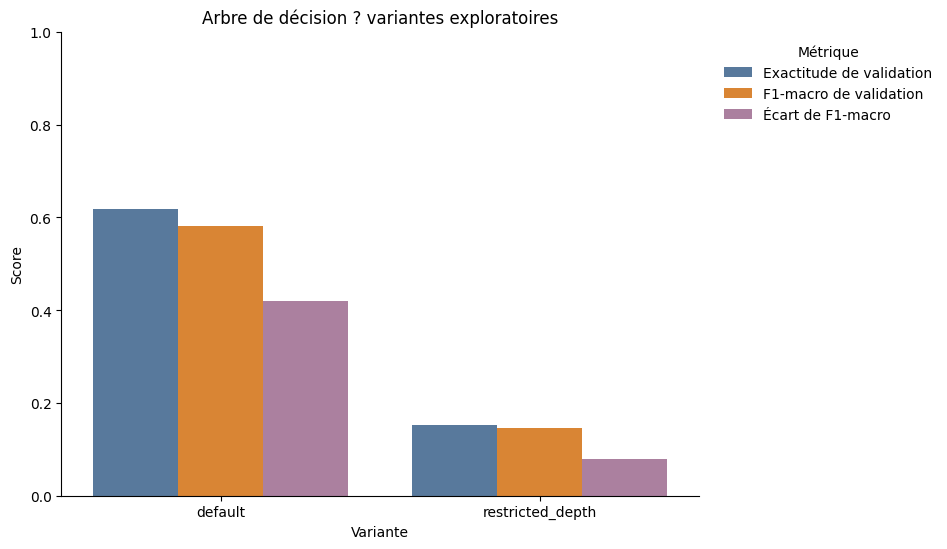

In [4]:
untuned_results = evaluer_variantes_untuned(ctx)
untuned_table = construire_tableau_variantes(untuned_results, None)
gap_table = construire_tableau_gaps(untuned_results)

display(untuned_table.round(4))
display(gap_table.round(4))

tracer_comparaison_variantes(
    untuned_table[[
        "variante",
        "val_accuracy_mean",
        "val_f1_macro_mean",
        "generalization_gap_f1_macro",
    ]],
    ["val_accuracy_mean", "val_f1_macro_mean", "generalization_gap_f1_macro"],
    titre=f"{definition['nom_affiche']} ? variantes exploratoires",
)
plt.show()


## 4. Résultat confirmatoire tuned

Les cartes du `GridSearchCV` restent exploratoires. La seule performance finale a commenter
comme resultat confirmatoire est la ligne `tuned` obtenue en `nested CV`.


In [5]:
tuning = executer_tuning_confirmatoire(ctx, untuned_results)
summary_table = construire_tableau_variantes(untuned_results, tuning["metrics"])
fold_table = construire_tableau_plis_externes(tuning["nested"])
grid_results = tuning["grid_results"].copy()
shortlist = grid_results.sort_values("rank_test_f1_macro").head(10)

display(summary_table.round(4))
display(fold_table.round(4))

colonnes_shortlist = [
    colonne
    for colonne in [
        "rank_test_f1_macro",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_fit_time",
    ] + [col for col in shortlist.columns if col.startswith("param_")]
    if colonne in shortlist.columns
]
display(shortlist[colonnes_shortlist].round(4))

if spec.tuning_heatmap_axes is not None:
    axe_x, axe_y = spec.tuning_heatmap_axes
    colonne_facette = spec.tuning_facet_column
    if colonne_facette and colonne_facette in grid_results.columns:
        for valeur_facette, sous_tableau in grid_results.groupby(colonne_facette):
            if sous_tableau[[axe_x, axe_y]].drop_duplicates().shape[0] != len(sous_tableau):
                continue
            tracer_heatmap_tuning(
                sous_tableau,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} - tuning exploratoire ({colonne_facette}={valeur_facette})",
            )
            plt.show()
    elif axe_x in grid_results.columns and axe_y in grid_results.columns:
        if grid_results[[axe_x, axe_y]].drop_duplicates().shape[0] == len(grid_results):
            tracer_heatmap_tuning(
                grid_results,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} - tuning exploratoire",
            )
            plt.show()
        else:
            tracer_hyperparametre_vs_performance(
                grid_results,
                x=axe_x,
                y="mean_test_f1_macro",
                hue=axe_y,
                titre=f"{definition['nom_affiche']} - lecture exploratoire du tuning",
            )
            plt.show()


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,default,simple_cv,baseline,0.6174,0.0386,0.5809,0.0425,1.0000,1.0000,0.3826,0.4191,0.9278,cv_n_jobs=1
1,tuned,nested_cv,tuned,0.4610,0.0627,0.4295,0.0546,NaN,NaN,NaN,NaN,12.1969,cv_n_jobs=1
2,restricted_depth,simple_cv,improved_untuned,0.1529,0.0270,0.1468,0.0277,0.2541,0.2265,0.1012,0.0797,0.4912,cv_n_jobs=1


,fold,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,fit_time,score_time,best_score_inner
0,1,0.5261,0.4806,0.3585,0.3402,2.4415,0.0009,0.2567
1,2,0.6777,0.6626,0.4654,0.4410,2.3590,0.0009,0.2404
2,3,0.7681,0.7376,0.4937,0.4562,2.2604,0.0010,0.2778
3,4,0.7666,0.7579,0.4620,0.4248,2.8340,0.0013,0.2672
4,5,0.8028,0.7795,0.5253,0.4851,2.2753,0.0010,0.2959


,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_fit_time,param_ccp_alpha,param_criterion,param_max_depth,param_min_samples_leaf
2,1,0.3016,0.0320,0.1664,0.000,gini,20,1
7,2,0.2949,0.0251,0.1332,0.005,gini,20,4
3,3,0.2944,0.0262,0.1408,0.000,gini,20,4
6,4,0.2931,0.0313,0.1380,0.005,gini,20,1
0,5,0.1112,0.0084,0.0931,0.000,gini,10,1
1,6,0.1109,0.0148,0.0819,0.000,gini,10,4
5,7,0.1093,0.0130,0.0777,0.005,gini,10,4
4,8,0.1058,0.0079,0.0754,0.005,gini,10,1


## 5. Vérifications de validité scientifique

Cette section impose le même contrat minimal dans tous les notebooks :
référence DummyClassifier, test de bruit aléatoire et rappel protocolaire.


In [6]:
validite = executer_verifications_validite(ctx)
display(Markdown(f"**Note protocolaire.** {validite['note']}"))
display(validite["dummy"].round(4))
display(validite["random_noise"].round(4))


**Note protocolaire.** Les variantes non tunées restent exploratoires ; les figures réapprises sur le sous-ensemble de développement (80 %) aussi. Les prédictions OOF de la variante tuned sont des diagnostics descriptifs confirmatoires, mais seul le score tuned en nested CV sert au classement final inter-modèles.

,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,reference
0,0.0063,0.0,0.0001,0.0,0.011,0.0002,0.0007,0.0016,0.022,5,dummy,most_frequent,DummyClassifier


,val_accuracy_mean,val_f1_macro_mean,chance_level,near_chance,reference
0,0.0114,0.0085,0.0101,True,Bruit aleatoire


## 6. Diagnostics du modele

Les tableaux et graphiques issus des predictions `OOF` de la `nested CV` sont confirmatoires.
Les diagnostics issus d'un refit global ou du `grid search` complet sont explicitement exploratoires.


,classe,precision,recall,f1,support,fpr,fnr,specificite
0,Betula_Pendula,0.0000,0.000,0.0000,8,0.0026,1.000,0.9974
1,Quercus_Coccifera,0.0000,0.000,0.0000,8,0.0000,1.000,1.0000
2,Pterocarya_Stenoptera,0.0000,0.000,0.0000,8,0.0000,1.000,1.0000
3,Zelkova_Serrata,0.0000,0.000,0.0000,8,0.0000,1.000,1.0000
4,Viburnum_Tinus,0.0000,0.000,0.0000,8,0.0013,1.000,0.9987
5,Quercus_Semecarpifolia,0.0000,0.000,0.0000,8,0.0153,1.000,0.9847
6,Quercus_Infectoria_sub,0.0000,0.000,0.0000,8,0.0000,1.000,1.0000
7,Quercus_Kewensis,0.0000,0.000,0.0000,8,0.0000,1.000,1.0000
8,Quercus_Greggii,0.2500,0.125,0.1667,8,0.0038,0.875,0.9962
9,Quercus_Phillyraeoides,0.5000,0.125,0.2000,8,0.0013,0.875,0.9987


,classe_vraie,classe_predite,nombre_erreurs
0,Lithocarpus_Cleistocarpus,Lithocarpus_Edulis,4
1,Acer_Capillipes,Acer_Opalus,3
2,Celtis_Koraiensis,Acer_Rubrum,3
3,Ginkgo_Biloba,Fagus_Sylvatica,3
4,Quercus_Crassifolia,Acer_Opalus,3
5,Quercus_Shumardii,Quercus_Palustris,3
6,Acer_Capillipes,Acer_Rufinerve,2
7,Acer_Circinatum,Betula_Austrosinensis,2
8,Acer_Pictum,Fagus_Sylvatica,2
9,Acer_Rubrum,Acer_Opalus,2


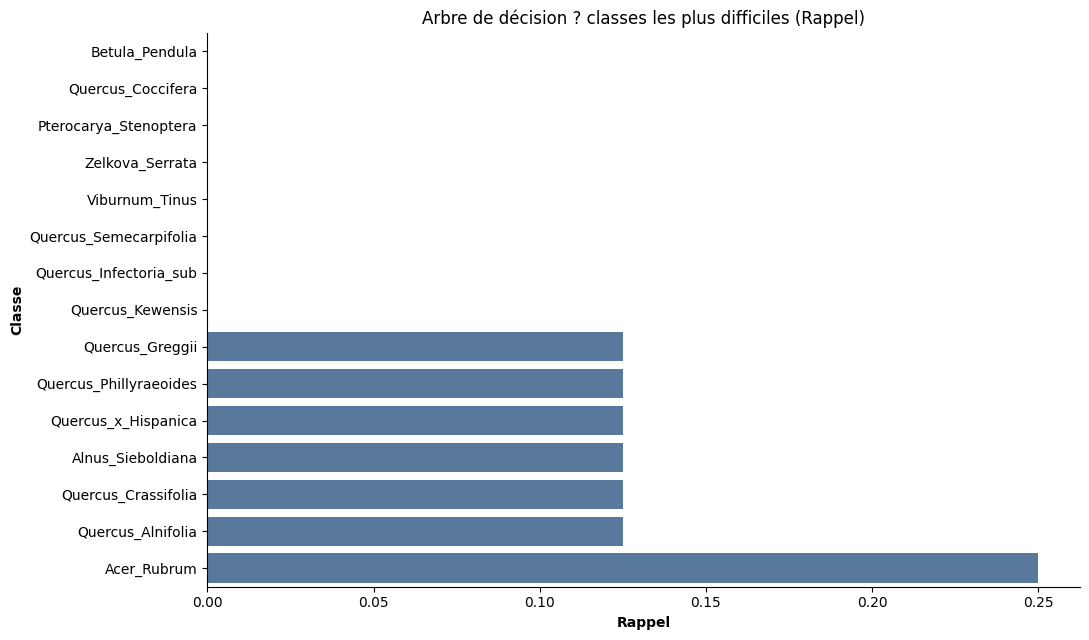

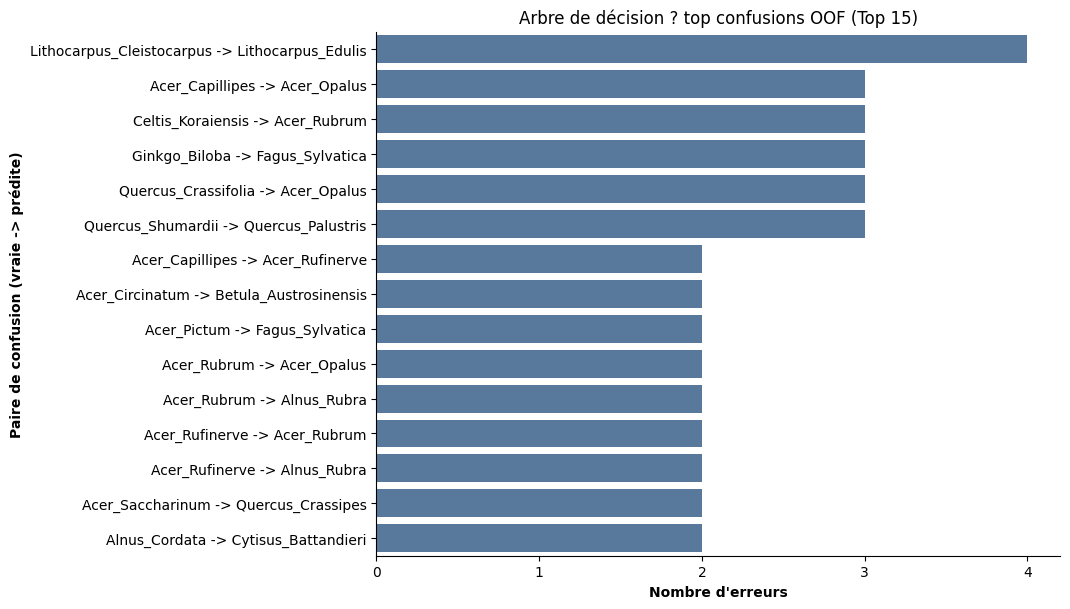

_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._

In [7]:
predictions_tuned = tuning["nested"]["oof_predictions"]
classes_table = calculer_metriques_classes_depuis_predictions(predictions_tuned, label_encoder)
difficult_classes = classes_difficiles(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
    metrique="recall",
)
confusions_table = top_confusions(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)

display(difficult_classes.round(4))
display(confusions_table.round(4))

tracer_metrique_par_classe(
    classes_table,
    metrique="recall",
    top_n=15,
    ordre="asc",
    titre=f"{definition['nom_affiche']} ? classes les plus difficiles",
)
plt.show()

if not confusions_table.empty:
    tracer_top_confusions(
        confusions_table,
        top_n=min(15, len(confusions_table)),
        titre=f"{definition['nom_affiche']} ? top confusions OOF",
    )
    plt.show()

probabilites_tuned = tuning["nested"].get("oof_probabilities")
if spec.supports_probabilities and probabilites_tuned is not None:
    topk = calculer_top_k_accuracies(probabilites_tuned)
    confiance = calculer_statistiques_confiance(probabilites_tuned)
    brier = calculer_brier_score_multiclasse(probabilites_tuned)
    tableau_probabilites = pd.DataFrame(
        [
            {
                "top_1_accuracy": topk["top_1_accuracy"],
                "top_5_accuracy": topk["top_5_accuracy"],
                "confiance_moyenne": confiance["confiance_moyenne"],
                "confiance_erreurs": confiance["confiance_erreurs"],
                "brier_multiclasse": brier,
            }
        ]
    )
    display(tableau_probabilites.round(4))
    tracer_histogramme_confiance(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? histogramme de confiance OOF",
    )
    plt.show()
    tracer_reliability_diagram(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? reliability diagram OOF",
    )
    plt.show()
else:
    display(Markdown("_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._"))


### Matrices de confusion par variante

Les matrices ci-dessous enrichissent la lecture des erreurs pour chaque variante du modele.
- pour `tuned`, les predictions proviennent des artefacts `OOF` de la `nested CV` ;
- pour les variantes non tunees, les predictions sont reconstruites en `simple CV` avec le protocole partage.

Cette comparaison reste descriptive : elle permet d'observer la structure des erreurs sans transformer
les variantes exploratoires en resultats confirmatoires.


,variante,evaluation_stage,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,confusion_dominante,nombre_erreurs_dominantes
0,default,baseline,0.5809,0.6174,0.4191,Alnus_Sieboldiana -> Alnus_Maximowiczii,3
1,restricted_depth,improved_untuned,0.1468,0.1529,0.0797,Acer_Capillipes -> Acer_Rubrum,4
2,tuned,tuned,0.4295,0.4610,NaN,Lithocarpus_Cleistocarpus -> Lithocarpus_Edulis,4


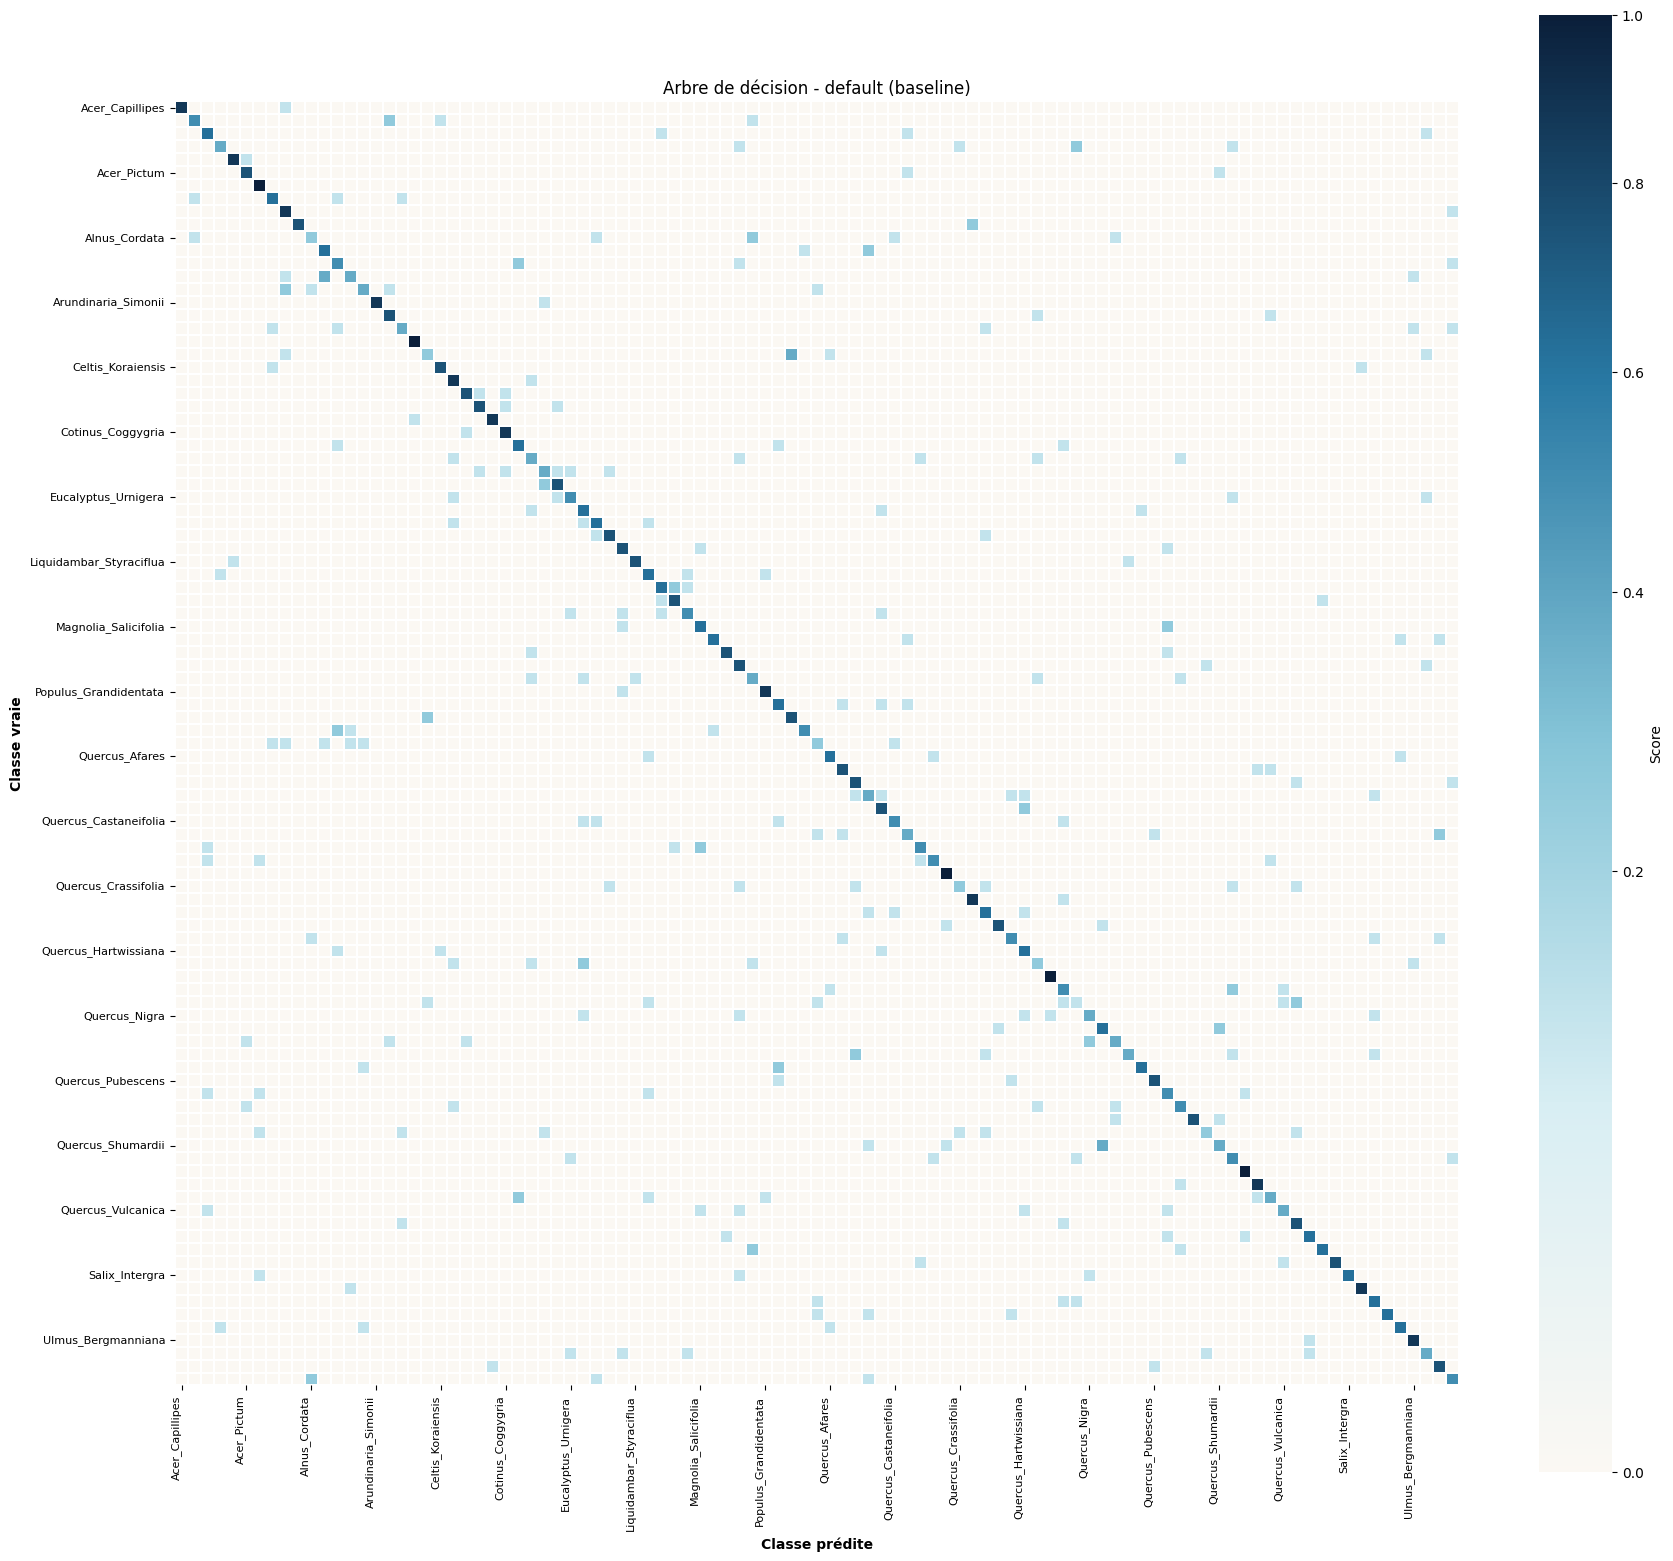

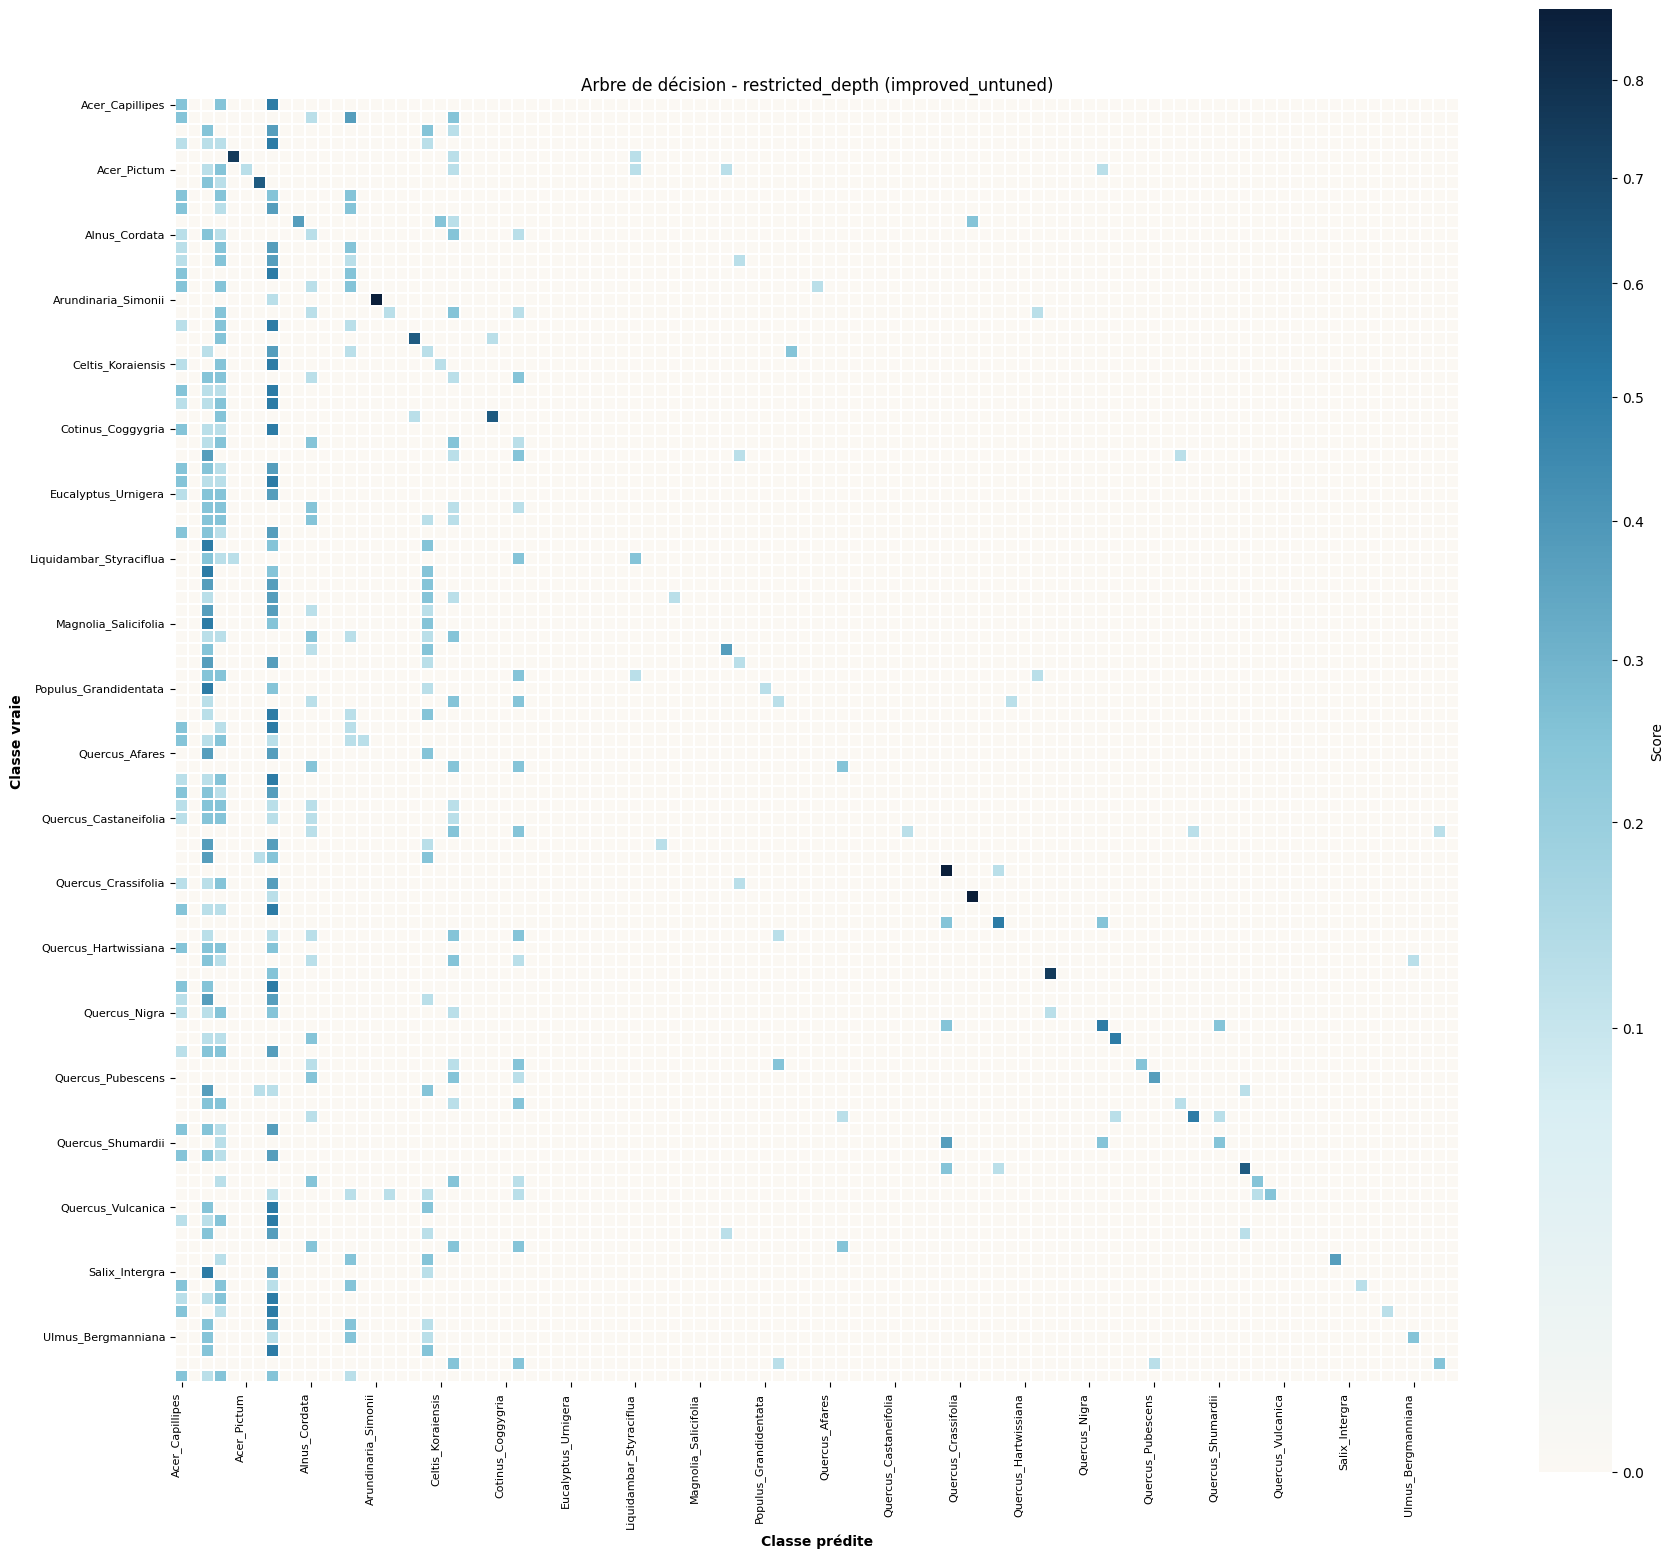

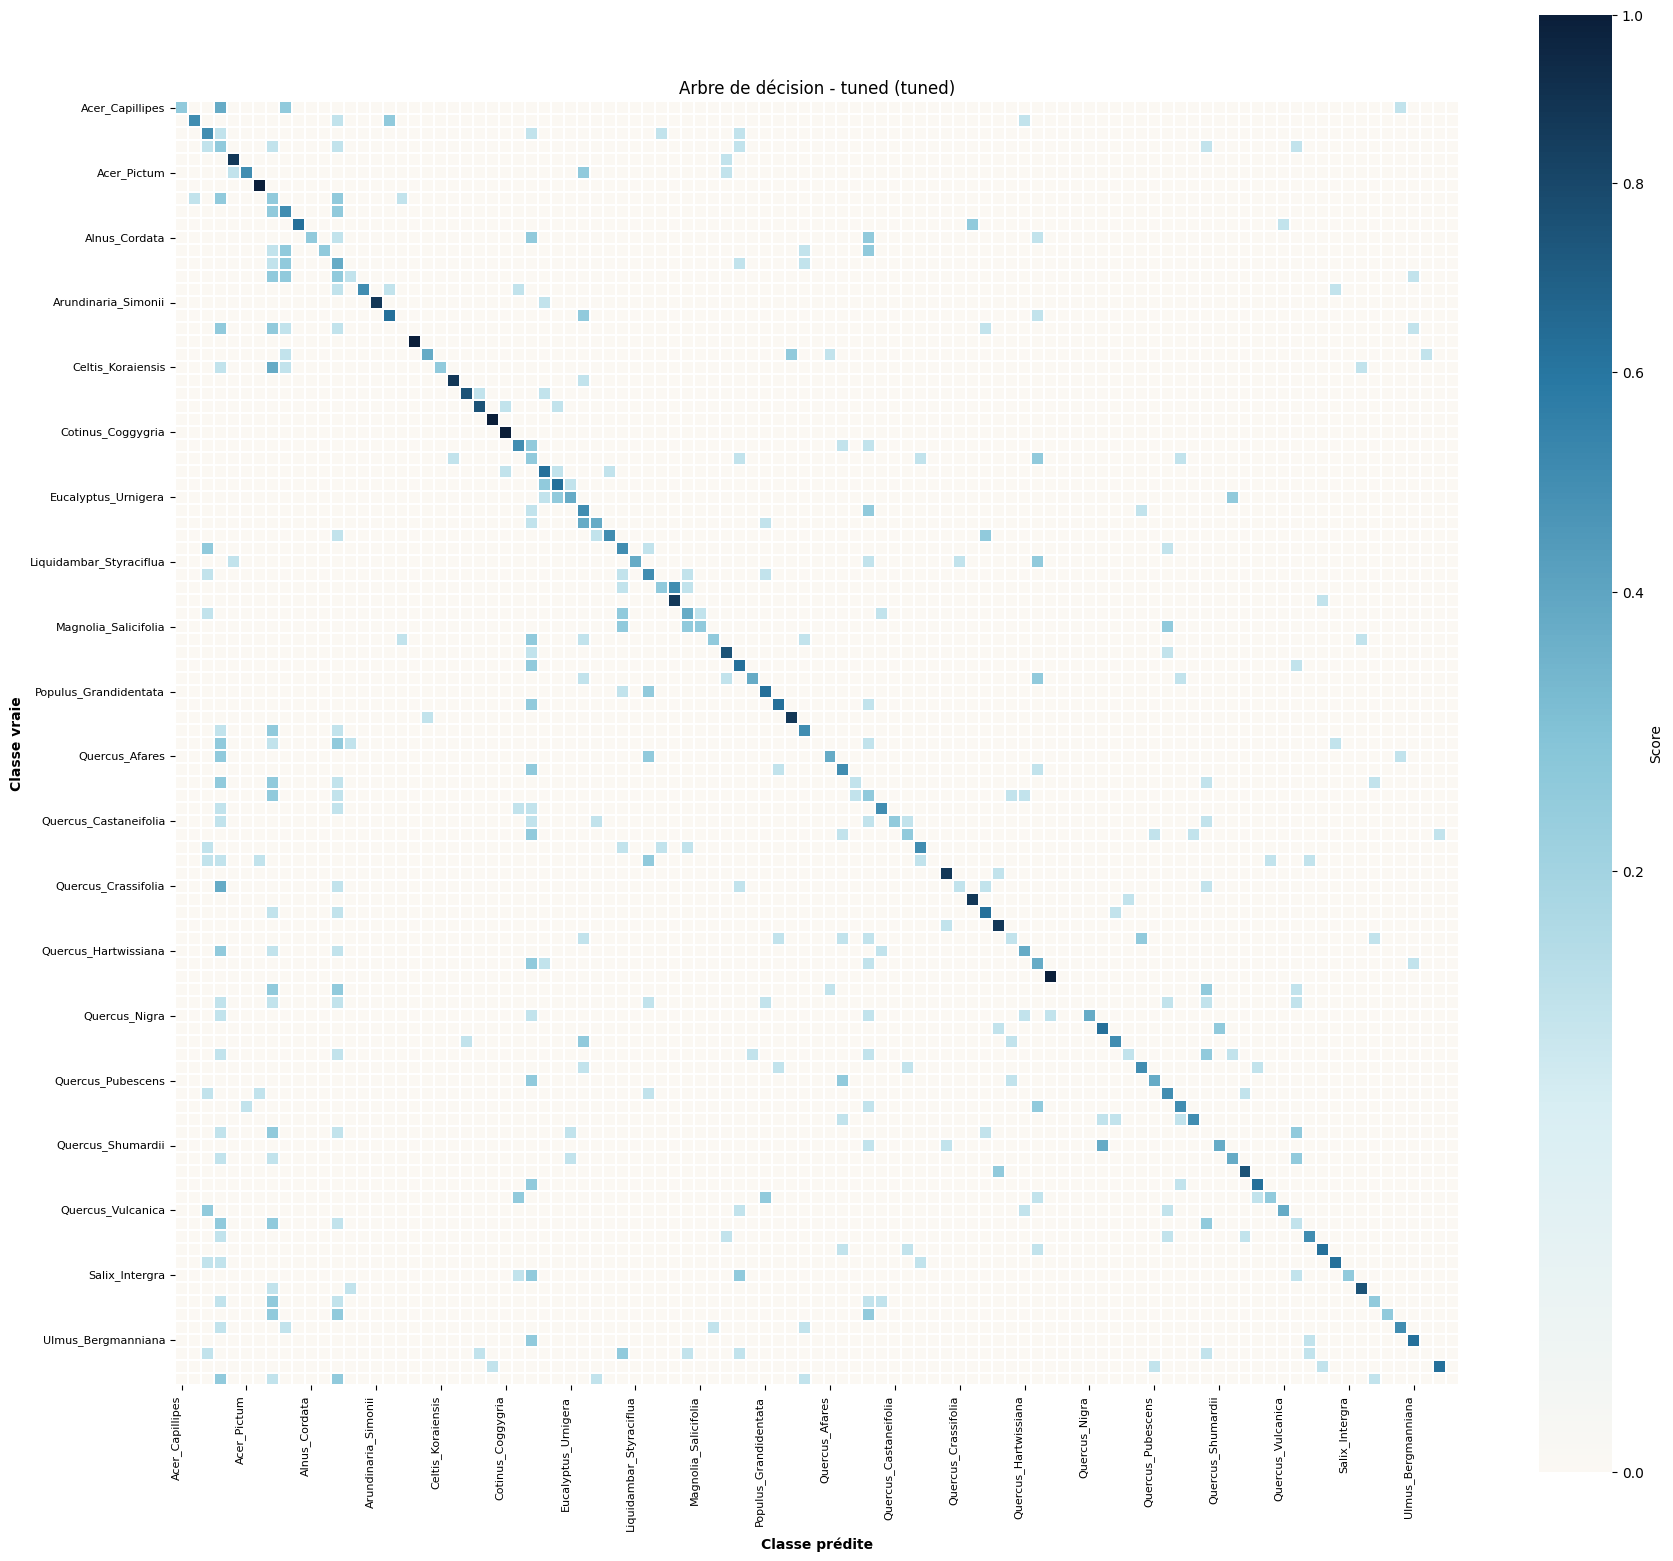

In [8]:
resume_confusions = construire_resume_confusions_variantes(
    MODEL_NAME,
    summary_table,
    X,
    y,
    label_encoder,
)
display(
    resume_confusions[[
        "variante",
        "evaluation_stage",
        "val_f1_macro_mean",
        "val_accuracy_mean",
        "generalization_gap_f1_macro",
        "confusion_dominante",
        "nombre_erreurs_dominantes",
    ]].round(4)
)

ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    resume_confusions
    .assign(
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["_ordre", "variante"])
    .reset_index(drop=True)
)

for ligne in catalogue_variantes.to_dict("records"):
    variante = str(ligne["variante"])
    predictions_variante = charger_ou_generer_predictions_variante(
        MODEL_NAME,
        variante,
        X,
        y,
        label_encoder=label_encoder,
        root=OUTPUT_ROOT,
    )
    matrice = matrice_confusion_normalisee(
        predictions_variante["y_true"].to_numpy(),
        predictions_variante["y_pred"].to_numpy(),
        label_encoder=label_encoder,
    )
    tracer_matrice_confusion(
        matrice,
        titre=f"{definition['nom_affiche']} - {variante} ({ligne['evaluation_stage']})",
        annot=False,
        intervalle_ticks=5,
    )
    plt.show()


_Diagnostic exploratoire specifique._ Les importances ci-dessous proviennent d'un refit global
du meilleur estimateur exploratoire. Elles servent a illustrer des tendances descriptives et ne
doivent pas etre interpretees causalement.


In [9]:
importance = calculer_importance_permutation_exploratoire(
    tuning["grid"].best_estimator_,
    X,
    y,
    n_repeats=5,
)
display(importance.head(20).round(4))


,feature,importance_mean,importance_std
0,shape47,0.2827,0.0083
1,shape62,0.1943,0.0138
2,margin59,0.1318,0.0038
3,shape14,0.0810,0.0052
4,margin39,0.0765,0.0033
5,margin4,0.0654,0.0071
6,margin49,0.0601,0.0028
7,texture61,0.0582,0.0052
8,texture9,0.0562,0.0054
9,margin18,0.0435,0.0035


### Compromis profondeur / performance — diagnostic exploratoire

Validation curve montrant le score train et validation en fonction de `max_depth`.
Ce diagnostic illustre le compromis biais-variance specifique a l'arbre de decision.

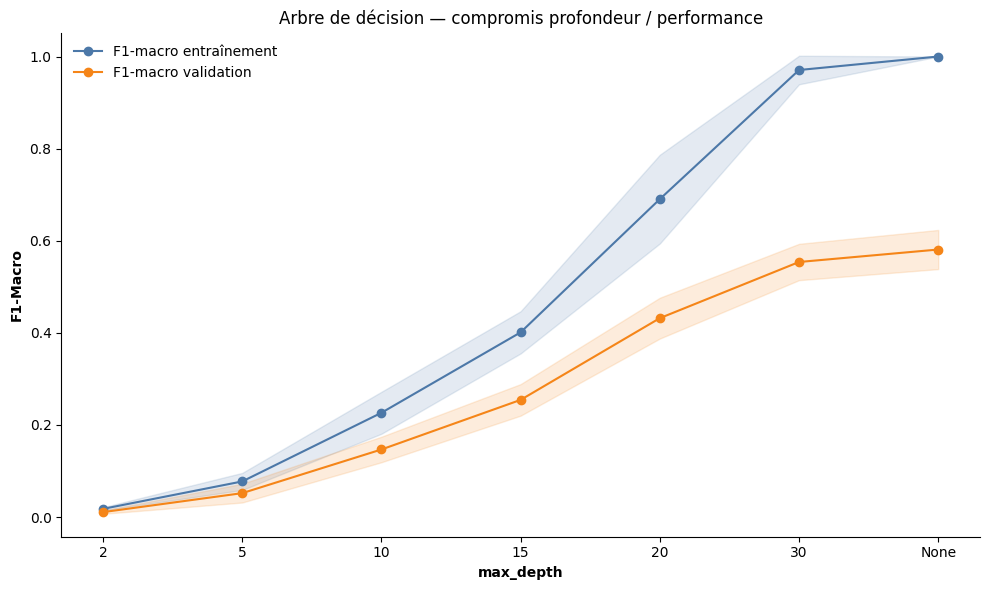

,max_depth,train_mean,train_std,val_mean,val_std
0,2,0.0179,0.0035,0.0108,0.0037
1,5,0.0774,0.0185,0.0520,0.0204
2,10,0.2265,0.0456,0.1468,0.0277
3,15,0.4012,0.0458,0.2545,0.0343
4,20,0.6904,0.0963,0.4320,0.0443
5,30,0.9707,0.0310,0.5539,0.0395
6,None,1.0000,0.0000,0.5809,0.0425


In [10]:
from src.models.pipelines import creer_estimateur

depth_data = validation_curve_max_depth(
    creer_estimateur("arbre_decision"),
    X, y,
)
tracer_validation_curve_max_depth(
    depth_data,
    titre=f"{definition['nom_affiche']} — compromis profondeur / performance",
)
plt.show()
display(depth_data.round(4))

## 7. Interpretation

Le texte ci-dessous reste automatiquement borne par les chiffres obtenus dans ce notebook.
Il ne doit pas servir a sur-interpreter des signaux purement exploratoires.


In [11]:
best_untuned = untuned_table.sort_values("val_f1_macro_mean", ascending=False).iloc[0]
tuned_row = summary_table.loc[summary_table["variante"] == "tuned"].iloc[0]
lignes = [
    f"- Meilleure variante non tunée : `{best_untuned['variante']}` avec F1-macro = `{best_untuned['val_f1_macro_mean']:.4f}`.",
    f"- Estimation confirmatoire `tuned` en validation croisée imbriquée : F1-macro = `{tuned_row['val_f1_macro_mean']:.4f}` et accuracy = `{tuned_row['val_accuracy_mean']:.4f}`.",
]

delta_tuning = tuned_row["val_f1_macro_mean"] - best_untuned["val_f1_macro_mean"]
if abs(delta_tuning) < 0.005:
    lignes.append(
        "- L'ajustement ne change pas matériellement la lecture scientifique par rapport à la meilleure variante exploratoire."
    )
elif delta_tuning > 0:
    lignes.append(
        f"- L'ajustement confirme un gain de `{delta_tuning:+.4f}` en F1-macro par rapport à la meilleure variante exploratoire."
    )
else:
    lignes.append(
        f"- La validation croisée imbriquée donne une estimation plus prudente que l'exploration en CV simple (delta F1-macro = `{delta_tuning:+.4f}`)."
    )

display(Markdown("\n".join(lignes)))


- Meilleure variante non tunée : `default` avec F1-macro = `0.5809`.
- Estimation confirmatoire `tuned` en validation croisée imbriquée : F1-macro = `0.4295` et accuracy = `0.4610`.
- La validation croisée imbriquée donne une estimation plus prudente que l'exploration en CV simple (delta F1-macro = `-0.1515`).

### Figure finale des variantes pour le rapport

Cette cellule lit les metriques canoniques dans `results/<modele>/metrics/`, reconstruit le tableau final des variantes et regenere la figure de synthese du rapport, en incluant explicitement la variante `tuned`.

,variante,f1_macro,accuracy,evaluation_stage,statut
0,default,0.5809,0.6174,baseline,exploratoire
1,restricted_depth,0.1468,0.1529,improved_untuned,exploratoire
2,tuned,0.4295,0.4610,tuned,confirmatoire


WindowsPath('docs/figures/fig_dt_comparaison_variantes.png')

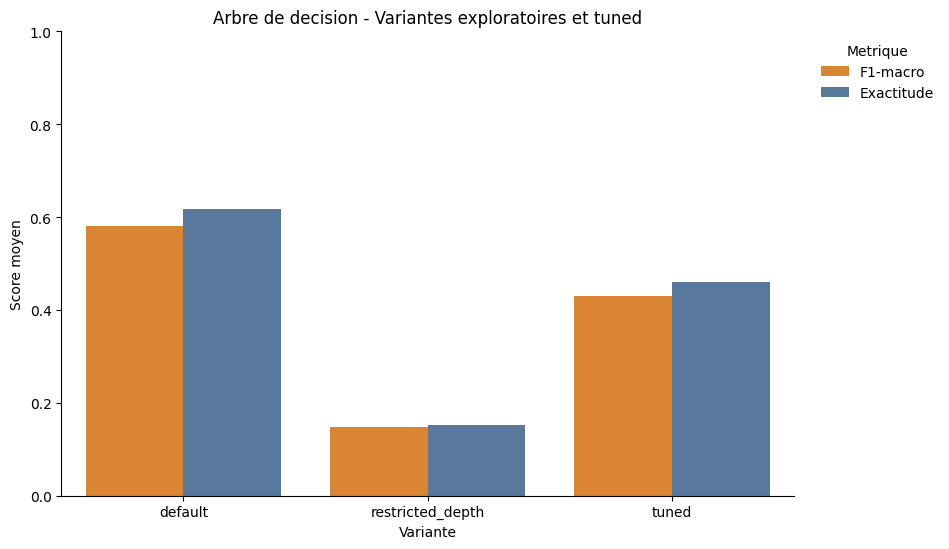

In [12]:
from pathlib import Path

from src.notebook_support import (
    charger_tableau_variantes_modele,
    construire_tableau_variantes_rapport,
)
from src.plots import tracer_comparaison_variantes_rapport

summary_table_report = charger_tableau_variantes_modele("arbre_decision")
display(construire_tableau_variantes_rapport(summary_table_report).round(4))

ax = tracer_comparaison_variantes_rapport(
    summary_table_report,
    titre="Arbre de decision - Variantes exploratoires et tuned",
)
output_path = Path("docs/figures/fig_dt_comparaison_variantes.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(output_path, dpi=170, bbox_inches="tight")
output_path
